# Retail Insight — Data Ingestion, Wrangling and EDA Notebook

This notebook is the **data ingestion layer** for the Retail Insight Cancellation Intelligence pipeline.

**What it does:**
1. Accepts uploaded Excel or CSV files via an interactive file picker
2. Validates schema and referential integrity across all tables
3. Performs full EDA on each table (shape, dtypes, missing values, distributions, anomalies)
4. Applies data transformations and wrangling (date parsing, type coercion, derived columns, outlier flagging)
5. Runs cross-table data quality checks and produces a structured quality report
6. Exports clean, processed data as Parquet files to `../data/processed/`
7. Verifies pipeline readiness before handing off to the FastAPI backend

**Output:** The pipeline loader (`backend/pipeline/loader.py`) automatically prefers the processed Parquet files
over the raw Excel file when they are present.

---


## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import io
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 4),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RI_BLUE  = "#1B3A6B"
RI_TEAL  = "#00A8E0"
RI_RED   = "#E63946"
RI_AMBER = "#F4A261"
RI_GREEN = "#2A9D8F"

# ── Output paths ──────────────────────────────────────────────────────────────
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR = Path("../data")

# ── Quality report accumulator ───────────────────────────────────────────────
quality_report = []

def qcheck(name, passed, detail=""):
    status = "✅ PASS" if passed else "❌ FAIL"
    quality_report.append({"check": name, "status": status, "detail": detail})
    print(f"  {status}  {name}" + (f" — {detail}" if detail else ""))

def section(title):
    print()
    print("=" * 70)
    print(f"  {title}")
    print("=" * 70)

print("Environment ready.")
print(f"Output directory: {PROCESSED_DIR.resolve()}")

Environment ready.
Output directory: C:\Hub\Projects\Titek\Data\retail_intelligence\retail\retail_insight\data\processed


---
## 1. File Upload

Upload your source file below. Supported formats:
- **Excel workbook** (`.xlsx`) containing sheets: Orders, Cancels, Inventory, Store, Product, Calendar
- **Individual CSV files** — one per table, named after the table (e.g. `orders.csv`, `cancels.csv`)

If you are running from the project directory, the raw `data.xlsx` will be auto-detected and you can skip the upload.


In [2]:
# ── Auto-detect existing raw file ────────────────────────────────────────────
DEFAULT_EXCEL = RAW_DIR / "data.xlsx"
raw_sheets = {}
upload_status = widgets.Output()

def load_from_excel(path):
    global raw_sheets
    sheets = pd.read_excel(path, sheet_name=None)
    raw_sheets = {k.upper(): v for k, v in sheets.items()}
    print(f"Loaded {len(raw_sheets)} sheets from {path}")
    for name, df in raw_sheets.items():
        print(f"  {name:15s}  {df.shape[0]:>7,} rows  x  {df.shape[1]} cols")

if DEFAULT_EXCEL.exists():
    print(f"Auto-detected: {DEFAULT_EXCEL}")
    load_from_excel(DEFAULT_EXCEL)
else:
    print("No default file found. Use the uploader below.")

Auto-detected: ..\data\data.xlsx
Loaded 6 sheets from ..\data\data.xlsx
  ORDERS            59,068 rows  x  5 cols
  CANCELS            7,408 rows  x  8 cols
  INVENTORY        221,217 rows  x  4 cols
  STORE                 15 rows  x  4 cols
  PRODUCT              174 rows  x  8 cols
  CALENDAR             366 rows  x  3 cols


In [3]:
# ── Interactive uploader ─────────────────────────────────────────────────────
uploader = widgets.FileUpload(
    accept=".xlsx,.csv",
    multiple=True,
    description="Upload files",
    button_style="primary",
    layout=widgets.Layout(width="350px")
)
load_btn   = widgets.Button(description="Load Uploaded Files", button_style="success",
                             layout=widgets.Layout(width="200px"))
status_out = widgets.Output()

def on_load(b):
    global raw_sheets
    with status_out:
        clear_output()
        if not uploader.value:
            print("No files uploaded yet.")
            return
        for item in uploader.value:
            fname = item["name"].lower()
            content = item["content"]
            if fname.endswith(".xlsx"):
                buf = io.BytesIO(bytes(content))
                load_from_excel(buf)
                print("Excel loaded via uploader.")
            elif fname.endswith(".csv"):
                table_name = Path(fname).stem.upper()
                raw_sheets[table_name] = pd.read_csv(io.BytesIO(bytes(content)))
                print(f"CSV loaded as table: {table_name} — {raw_sheets[table_name].shape}")

load_btn.on_click(on_load)
display(widgets.VBox([
    widgets.HTML("<b>Optional: upload a different file</b>"),
    uploader,
    load_btn,
    status_out
]))

---
## 2. Schema Validation

Verify that all expected tables are present and contain the required columns.


In [4]:
section("SCHEMA VALIDATION")

EXPECTED_SCHEMA = {
    "ORDERS":    ["STORE_NUM","ORDER_DT","ITEM_ID","PLCD_QTY","PLCD_AMT"],
    "CANCELS":   ["STORE_NUM","ORDER_DT","CANCEL_DT","ITEM_ID",
                  "CNCL_RSN_DESC","CNCL_QTY","CNCL_AMT"],
    "INVENTORY": ["STORE_NUM","ITEM_ID","GREGORIAN_DATE","ON_HAND_QTY"],
    "STORE":     ["STORE_NUM","CITY","STATE","REGION"],
    "PRODUCT":   ["ITEM_ID","PRODUCT_NAME","DEPARTMENT","CATEGORY","BRAND",
                  "ACTIVE_STATUS","ACTIVE_DATE","UNIT_COST"],
    "CALENDAR":  ["DATE","DAYOFWEEK","WEEK #"],
}

for table, required_cols in EXPECTED_SCHEMA.items():
    if table not in raw_sheets:
        qcheck(f"Table present: {table}", False, "MISSING")
        continue
    df = raw_sheets[table]
    actual_cols = [c.upper() for c in df.columns]
    missing = [c for c in required_cols if c not in actual_cols]
    qcheck(f"Table present: {table}", True, f"{df.shape[0]:,} rows")
    qcheck(f"  Required columns: {table}", len(missing)==0,
           "OK" if not missing else f"Missing: {missing}")

# Normalise column names to upper for downstream consistency
raw_sheets = {
    k: df.rename(columns={c: c.upper() for c in df.columns})
    for k, df in raw_sheets.items()
}

# Also normalise CALENDAR date column name
if "CALENDAR" in raw_sheets:
    cal = raw_sheets["CALENDAR"]
    # rename DATE if it exists
    if "DATE" in cal.columns and "DATE" not in ["DATE"]:
        pass
    raw_sheets["CALENDAR"] = cal.rename(columns={"DATE":"CAL_DATE"})


  SCHEMA VALIDATION
  ✅ PASS  Table present: ORDERS — 59,068 rows
  ✅ PASS    Required columns: ORDERS — OK
  ✅ PASS  Table present: CANCELS — 7,408 rows
  ✅ PASS    Required columns: CANCELS — OK
  ✅ PASS  Table present: INVENTORY — 221,217 rows
  ✅ PASS    Required columns: INVENTORY — OK
  ✅ PASS  Table present: STORE — 15 rows
  ✅ PASS    Required columns: STORE — OK
  ✅ PASS  Table present: PRODUCT — 174 rows
  ✅ PASS    Required columns: PRODUCT — OK
  ✅ PASS  Table present: CALENDAR — 366 rows
  ✅ PASS    Required columns: CALENDAR — OK


---
## 3. Exploratory Data Analysis

Full profile of each table: dtypes, missing values, cardinality, value distributions.


In [5]:
def profile_table(name, df, date_cols=None):
    print(f"\n{'─'*60}")
    print(f"  TABLE: {name}  ({df.shape[0]:,} rows x {df.shape[1]} cols)")
    print(f"{'─'*60}")

    # Dtypes and nulls
    summary = pd.DataFrame({
        "dtype":     df.dtypes.astype(str),
        "nulls":     df.isnull().sum(),
        "null_pct":  (df.isnull().mean()*100).round(1),
        "unique":    df.nunique(),
        "sample":    [df[c].dropna().iloc[0] if df[c].notna().any() else "ALL NULL"
                      for c in df.columns],
    })
    display(summary)

    # Numeric distributions
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if num_cols:
        display(df[num_cols].describe().round(2))


  EDA — ORDERS

────────────────────────────────────────────────────────────
  TABLE: ORDERS  (59,068 rows x 5 cols)
────────────────────────────────────────────────────────────


,dtype,nulls,null_pct,unique,sample
STORE_NUM,int64,0,0.0,15,12
ORDER_DT,datetime64[ns],0,0.0,144,2024-02-01 00:00:00
ITEM_ID,int64,0,0.0,153,994003
PLCD_QTY,int64,0,0.0,148,1
PLCD_AMT,float64,0,0.0,4490,1.78


,STORE_NUM,ITEM_ID,PLCD_QTY,PLCD_AMT
count,59068.00,5.906800e+04,59068.00,59068.00
mean,1714.19,2.199500e+08,4.90,19.20
std,1776.31,4.204272e+08,10.76,55.50
min,12.00,3.238900e+04,1.00,0.00
25%,158.00,5.783239e+06,1.00,3.68
50%,1357.00,2.873244e+07,2.00,6.50
75%,2095.00,2.591050e+08,4.00,13.38
max,6530.00,4.005958e+09,187.00,989.72


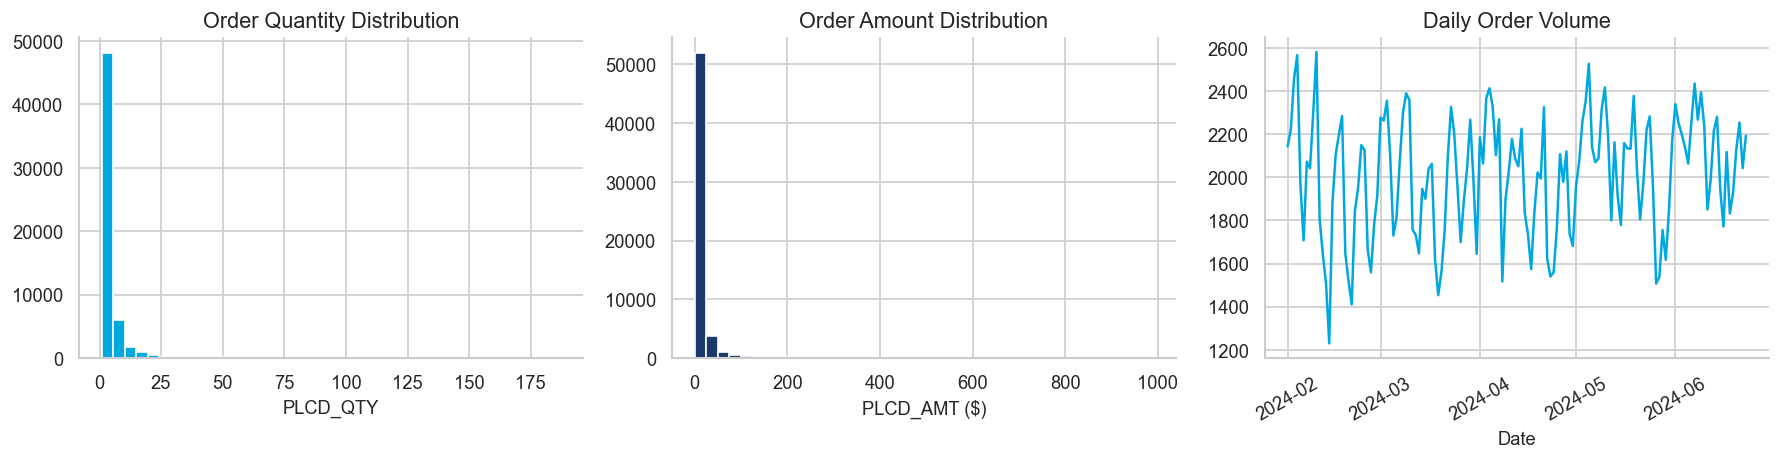

Stores in orders: 15
Items in orders:  153
Date range:       2024-02-01 to 2024-06-23


In [6]:
section("EDA — ORDERS")
orders_raw = raw_sheets["ORDERS"].copy()
profile_table("ORDERS", orders_raw)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(orders_raw["PLCD_QTY"], bins=40, color=RI_TEAL, edgecolor="white")
axes[0].set_title("Order Quantity Distribution")
axes[0].set_xlabel("PLCD_QTY")

axes[1].hist(orders_raw["PLCD_AMT"], bins=40, color=RI_BLUE, edgecolor="white")
axes[1].set_title("Order Amount Distribution")
axes[1].set_xlabel("PLCD_AMT ($)")

daily = orders_raw.copy()
daily["ORDER_DT"] = pd.to_datetime(daily["ORDER_DT"])
daily_agg = daily.groupby("ORDER_DT")["PLCD_QTY"].sum()
axes[2].plot(daily_agg.index, daily_agg.values, color=RI_TEAL, linewidth=1.5)
axes[2].set_title("Daily Order Volume")
axes[2].set_xlabel("Date")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
print(f"Stores in orders: {orders_raw['STORE_NUM'].nunique()}")
print(f"Items in orders:  {orders_raw['ITEM_ID'].nunique()}")
print(f"Date range:       {pd.to_datetime(orders_raw['ORDER_DT']).min().date()} to "
      f"{pd.to_datetime(orders_raw['ORDER_DT']).max().date()}")


  EDA — CANCELS

────────────────────────────────────────────────────────────
  TABLE: CANCELS  (7,408 rows x 8 cols)
────────────────────────────────────────────────────────────


,dtype,nulls,null_pct,unique,sample
STORE_NUM,int64,0,0.0,15,61
ORDER_DT,datetime64[ns],0,0.0,158,2024-01-31 00:00:00
CANCEL_DT,datetime64[ns],0,0.0,144,2024-02-01 00:00:00
ITEM_ID,int64,0,0.0,128,3528621
CNCL_RSN_DESC,object,0,0.0,22,Customer Cancellation
CNCL_RSN_SUB_DESC,object,3953,53.4,20,Used The Wrong Payment Method
CNCL_QTY,int64,0,0.0,22,10
CNCL_AMT,float64,735,9.9,675,13.4


,STORE_NUM,ITEM_ID,CNCL_QTY,CNCL_AMT
count,7408.00,7.408000e+03,7408.00,6673.00
mean,1704.64,2.098886e+08,1.75,7.61
std,1606.86,3.298318e+08,1.66,8.78
min,12.00,3.238900e+04,1.00,0.00
25%,158.00,1.068719e+07,1.00,3.18
50%,1426.00,6.852043e+07,1.00,5.36
75%,1691.00,2.488487e+08,2.00,9.94
max,6530.00,4.005958e+09,30.00,181.58


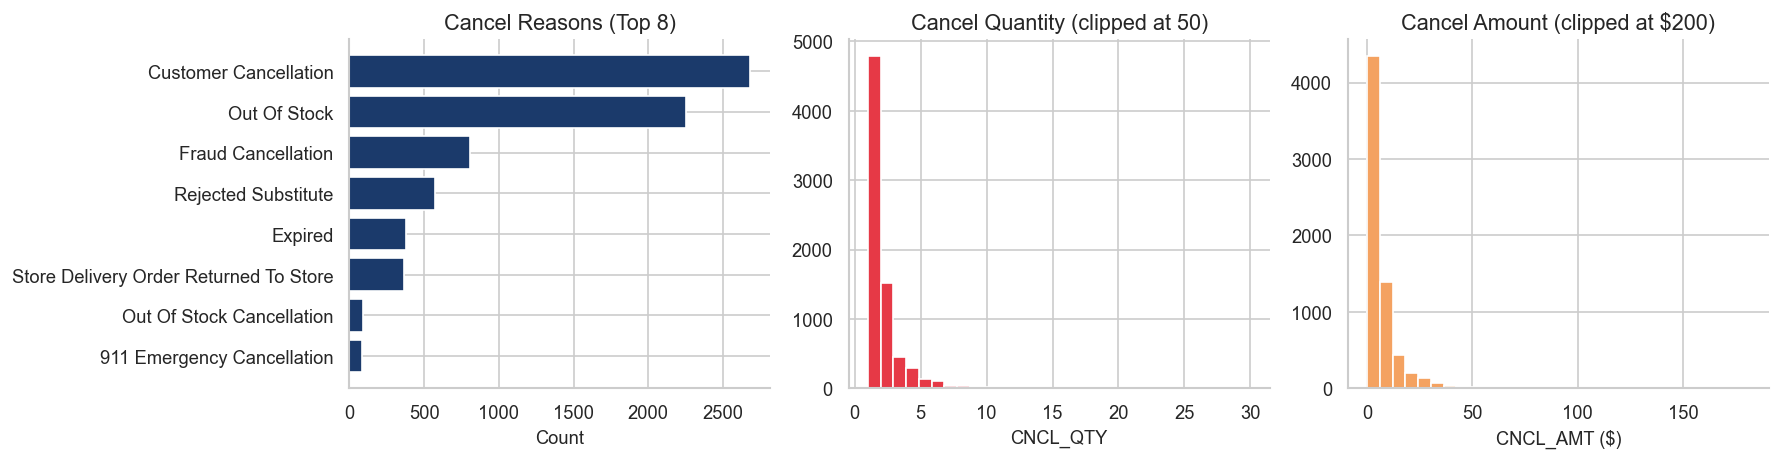


Sub-reasons (non-null):
CNCL_RSN_SUB_DESC
Would Not Arrive In Time                                 676
Customer Rejection - Rejected Substitute                 552
Other                                                    519
Used The Wrong Address                                   355
Used The Wrong Payment Method                            341
Other Items Cancelled, So I No Longer Want This          300
Ordered Wrong Item Or Amount                             220
Cancelled Due To Multiple  Returns                       184
No Action By Customer On Alternate Fulfillment Option     84
Did Not Place This Order                                  80


In [7]:
section("EDA — CANCELS")
cancels_raw = raw_sheets["CANCELS"].copy()
profile_table("CANCELS", cancels_raw)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Reason breakdown
reason_counts = cancels_raw["CNCL_RSN_DESC"].value_counts().head(8)
axes[0].barh(reason_counts.index[::-1], reason_counts.values[::-1], color=RI_BLUE)
axes[0].set_title("Cancel Reasons (Top 8)")
axes[0].set_xlabel("Count")

# Cancel qty distribution
axes[1].hist(cancels_raw["CNCL_QTY"].clip(upper=50), bins=30, color=RI_RED, edgecolor="white")
axes[1].set_title("Cancel Quantity (clipped at 50)")
axes[1].set_xlabel("CNCL_QTY")

# Cancel amount distribution
axes[2].hist(cancels_raw["CNCL_AMT"].clip(upper=200), bins=30, color=RI_AMBER, edgecolor="white")
axes[2].set_title("Cancel Amount (clipped at $200)")
axes[2].set_xlabel("CNCL_AMT ($)")

plt.tight_layout()
plt.show()

# Sub-reasons
print("\nSub-reasons (non-null):")
print(cancels_raw["CNCL_RSN_SUB_DESC"].value_counts().head(10).to_string())


  EDA — INVENTORY

────────────────────────────────────────────────────────────
  TABLE: INVENTORY  (221,217 rows x 4 cols)
────────────────────────────────────────────────────────────


,dtype,nulls,null_pct,unique,sample
STORE_NUM,int64,0,0.0,15,6530
ITEM_ID,int64,0,0.0,139,2343375921
GREGORIAN_DATE,datetime64[ns],0,0.0,142,2024-02-01 00:00:00
ON_HAND_QTY,int64,0,0.0,1131,25


,STORE_NUM,ITEM_ID,ON_HAND_QTY
count,221217.00,2.212170e+05,221217.00
mean,1837.13,3.619663e+08,32.20
std,1843.26,5.519523e+08,83.25
min,12.00,3.238900e+04,-181.00
25%,158.00,1.247860e+07,7.00
50%,1357.00,1.510168e+08,13.00
75%,2478.00,4.695170e+08,27.00
max,6530.00,2.805328e+09,2988.00


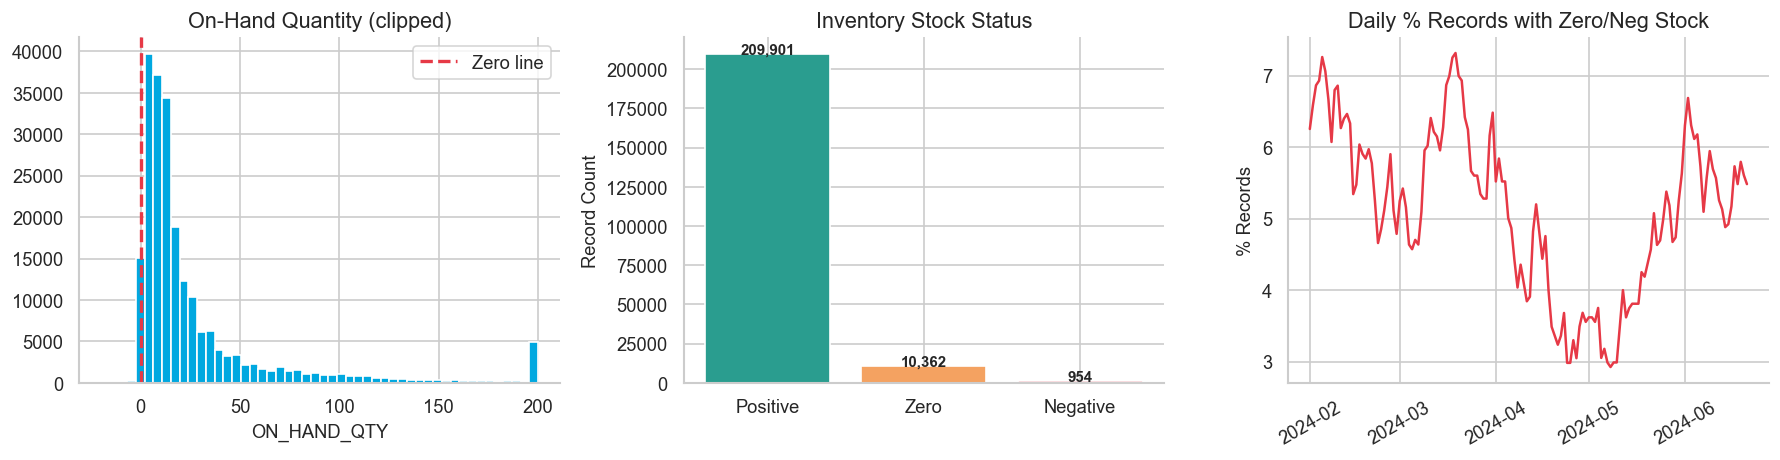


Inventory records: 221,217
Negative stock:    954 (0.43%)
Zero stock:        10,362 (4.68%)


In [8]:
section("EDA — INVENTORY")
inv_raw = raw_sheets["INVENTORY"].copy()
profile_table("INVENTORY", inv_raw)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# On-hand qty distribution
axes[0].hist(inv_raw["ON_HAND_QTY"].clip(-20, 200), bins=50, color=RI_TEAL, edgecolor="white")
axes[0].axvline(0, color=RI_RED, linewidth=2, linestyle="--", label="Zero line")
axes[0].set_title("On-Hand Quantity (clipped)")
axes[0].set_xlabel("ON_HAND_QTY")
axes[0].legend()

# Zero and negative inventory
zero_count = (inv_raw["ON_HAND_QTY"] == 0).sum()
neg_count  = (inv_raw["ON_HAND_QTY"] < 0).sum()
pos_count  = (inv_raw["ON_HAND_QTY"] > 0).sum()
axes[1].bar(["Positive", "Zero", "Negative"],
            [pos_count, zero_count, neg_count],
            color=[RI_GREEN, RI_AMBER, RI_RED])
axes[1].set_title("Inventory Stock Status")
axes[1].set_ylabel("Record Count")
for i, v in enumerate([pos_count, zero_count, neg_count]):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# Daily zero-stock rate
inv_raw["DATE"] = pd.to_datetime(inv_raw["GREGORIAN_DATE"])
daily_zero = inv_raw.groupby("DATE").apply(lambda x: (x["ON_HAND_QTY"]<=0).mean()*100)
axes[2].plot(daily_zero.index, daily_zero.values, color=RI_RED, linewidth=1.5)
axes[2].set_title("Daily % Records with Zero/Neg Stock")
axes[2].set_ylabel("% Records")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"\nInventory records: {len(inv_raw):,}")
print(f"Negative stock:    {neg_count:,} ({neg_count/len(inv_raw)*100:.2f}%)")
print(f"Zero stock:        {zero_count:,} ({zero_count/len(inv_raw)*100:.2f}%)")

In [9]:
section("EDA — STORE, PRODUCT, CALENDAR")

store_raw   = raw_sheets["STORE"].copy()
product_raw = raw_sheets["PRODUCT"].copy()
cal_raw     = raw_sheets["CALENDAR"].copy()

print("\nSTORE table:")
display(store_raw)

print("\nPRODUCT table summary:")
profile_table("PRODUCT", product_raw)
print("\nDepartments:")
print(product_raw["DEPARTMENT"].value_counts().to_string())
print("\nCategories:")
print(product_raw["CATEGORY"].value_counts().head(10).to_string())
print("\nActive Status:")
print(product_raw["ACTIVE_STATUS"].value_counts().to_string())

print("\nCALENDAR table:")
display(cal_raw.head(10))


  EDA — STORE, PRODUCT, CALENDAR

STORE table:


,STORE_NUM,CITY,STATE,REGION
0,12,Mountainview,IL,8
1,61,Wedington,TN,19
2,133,Clinton,IA,5
3,158,Springfield,IA,5
4,676,Acorn,IL,8
5,1290,Sherwood,AR,12
6,1357,Midtown,IA,5
7,1426,Alpine,IL,8
8,1691,Clarksville,AR,12
9,2095,Greenville,IA,5



PRODUCT table summary:

────────────────────────────────────────────────────────────
  TABLE: PRODUCT  (174 rows x 8 cols)
────────────────────────────────────────────────────────────


,dtype,nulls,null_pct,unique,sample
ITEM_ID,int64,0,0.0,153,994003
PRODUCT_NAME,object,26,14.9,148,"Instant Noodle Soup Mix Chicken Flavor Broth, ..."
DEPARTMENT,object,0,0.0,4,GROCERY
CATEGORY,object,0,0.0,16,SOUP
BRAND,object,26,14.9,25,StoreBrand
ACTIVE_STATUS,object,0,0.0,2,A
ACTIVE_DATE,datetime64[ns],0,0.0,144,2024-01-22 00:00:00
UNIT_COST,float64,0,0.0,169,0.386215


,ITEM_ID,UNIT_COST
count,1.740000e+02,174.00
mean,3.874905e+08,2.03
std,6.177190e+08,2.66
min,3.238900e+04,0.02
25%,1.267134e+07,0.47
50%,1.759621e+08,1.13
75%,5.010719e+08,2.68
max,4.005958e+09,18.67



Departments:
DEPARTMENT
STATIONERY              47
SNACKS AND BEVERAGES    46
GROCERY                 42
TOYS                    39

Categories:
CATEGORY
FLAVORED WATER        13
OFFICE SUPPLIES       12
ACTIVITY              12
SALTY SNACKS L3       12
MOVING SUPPLIES       12
BAKING GOODS          11
GAMES D7              11
SPICES AND SALT       11
SCHOOL SUPPLIES       11
NON FLAVORED WATER    11

Active Status:
ACTIVE_STATUS
A    153
D     21

CALENDAR table:


,CAL_DATE,DAYOFWEEK,WEEK #
0,2024-01-01,2,49
1,2024-01-02,3,49
2,2024-01-03,4,49
3,2024-01-04,5,49
4,2024-01-05,6,49
5,2024-01-06,7,50
6,2024-01-07,1,50
7,2024-01-08,2,50
8,2024-01-09,3,50
9,2024-01-10,4,50


---
## 4. Cross-Table Data Quality Checks

Referential integrity, date alignment, join key validation, and OOS paradox analysis.


In [10]:
section("CROSS-TABLE DATA QUALITY CHECKS")

orders_raw  = raw_sheets["ORDERS"].copy()
cancels_raw = raw_sheets["CANCELS"].copy()
inv_raw     = raw_sheets["INVENTORY"].copy()
store_raw   = raw_sheets["STORE"].copy()
product_raw = raw_sheets["PRODUCT"].copy()

# Parse dates early for checks
orders_raw["ORDER_DT"]  = pd.to_datetime(orders_raw["ORDER_DT"])
cancels_raw["ORDER_DT"] = pd.to_datetime(cancels_raw["ORDER_DT"])
cancels_raw["CANCEL_DT"]= pd.to_datetime(cancels_raw["CANCEL_DT"])
inv_raw["GREGORIAN_DATE"]= pd.to_datetime(inv_raw["GREGORIAN_DATE"])

store_ids   = set(store_raw["STORE_NUM"])
product_ids = set(product_raw["ITEM_ID"])

print("\n--- Referential Integrity ---")
ord_stores_missing = set(orders_raw["STORE_NUM"]) - store_ids
qcheck("Orders: all store IDs in Store table", len(ord_stores_missing)==0,
       f"{len(ord_stores_missing)} unknown stores" if ord_stores_missing else "OK")

cnl_stores_missing = set(cancels_raw["STORE_NUM"]) - store_ids
qcheck("Cancels: all store IDs in Store table", len(cnl_stores_missing)==0,
       f"{len(cnl_stores_missing)} unknown stores" if cnl_stores_missing else "OK")

ord_items_missing = set(orders_raw["ITEM_ID"]) - product_ids
qcheck("Orders: all item IDs in Product table", len(ord_items_missing)==0,
       f"{len(ord_items_missing)} unknown items" if ord_items_missing else "OK")

cnl_items_missing = set(cancels_raw["ITEM_ID"]) - product_ids
qcheck("Cancels: all item IDs in Product table", len(cnl_items_missing)==0,
       f"{len(cnl_items_missing)} unknown items" if cnl_items_missing else "OK")

print("\n--- Date Range Consistency ---")
ord_min, ord_max = orders_raw["ORDER_DT"].min(), orders_raw["ORDER_DT"].max()
cnl_min, cnl_max = cancels_raw["ORDER_DT"].min(), cancels_raw["ORDER_DT"].max()
inv_min, inv_max = inv_raw["GREGORIAN_DATE"].min(), inv_raw["GREGORIAN_DATE"].max()

print(f"  Orders:    {ord_min.date()} to {ord_max.date()}")
print(f"  Cancels:   {cnl_min.date()} to {cnl_max.date()}")
print(f"  Inventory: {inv_min.date()} to {inv_max.date()}")

date_mismatch = cnl_min < ord_min
qcheck("Cancel order dates within order date range", not date_mismatch,
       f"Cancels reference orders as early as {cnl_min.date()} but orders start {ord_min.date()}" if date_mismatch else "OK")

inv_gap = inv_max < ord_max
qcheck("Inventory covers full order period", not inv_gap,
       f"Inventory ends {inv_max.date()}, orders go to {ord_max.date()}" if inv_gap else "OK")

print("\n--- Cancel Logic Checks ---")
neg_lag = (cancels_raw["CANCEL_DT"] < cancels_raw["ORDER_DT"]).sum()
qcheck("Cancel date >= Order date (no negative lag)", neg_lag == 0,
       f"{neg_lag} records with cancel before order" if neg_lag else "OK")

neg_qty = (cancels_raw["CNCL_QTY"] <= 0).sum()
qcheck("Cancel quantities are positive", neg_qty == 0,
       f"{neg_qty} zero/negative cancel quantities" if neg_qty else "OK")

print("\n--- Inventory Checks ---")
neg_inv = (inv_raw["ON_HAND_QTY"] < 0).sum()
qcheck("No negative inventory values", neg_inv == 0,
       f"{neg_inv:,} negative records ({neg_inv/len(inv_raw)*100:.1f}% of inventory)" if neg_inv else "OK")

print("\n--- OOS Cancel Paradox Check ---")
oos_reasons = ["Out Of Stock", "Out Of Stock Cancellation"]
oos_cancels = cancels_raw[cancels_raw["CNCL_RSN_DESC"].isin(oos_reasons)].copy()
oos_inv = oos_cancels.merge(
    inv_raw.rename(columns={"GREGORIAN_DATE":"ORDER_DT"}),
    on=["STORE_NUM","ITEM_ID","ORDER_DT"], how="left"
)
matched = oos_inv[oos_inv["ON_HAND_QTY"].notna()]
if len(matched) > 0:
    pct_with_stock = (matched["ON_HAND_QTY"] > 0).mean() * 100
    qcheck("OOS cancels corroborate zero inventory",
           pct_with_stock < 20,
           f"{pct_with_stock:.0f}% of OOS-flagged cancels had POSITIVE inventory — reason code is unreliable")

print("\n--- Product Data Quality ---")
missing_names  = product_raw["PRODUCT_NAME"].isnull().sum()
missing_brands = product_raw["BRAND"].isnull().sum()
inactive       = (product_raw["ACTIVE_STATUS"] == "D").sum()
qcheck("Product names complete", missing_names == 0,
       f"{missing_names} products missing name" if missing_names else "OK")
qcheck("Product brands complete", missing_brands == 0,
       f"{missing_brands} products missing brand" if missing_brands else "OK")
qcheck("No inactive products in active catalogue", inactive == 0,
       f"{inactive} discontinued (D) products remain in catalogue" if inactive else "OK")


  CROSS-TABLE DATA QUALITY CHECKS

--- Referential Integrity ---
  ✅ PASS  Orders: all store IDs in Store table — OK
  ✅ PASS  Cancels: all store IDs in Store table — OK
  ✅ PASS  Orders: all item IDs in Product table — OK
  ✅ PASS  Cancels: all item IDs in Product table — OK

--- Date Range Consistency ---
  Orders:    2024-02-01 to 2024-06-23
  Cancels:   2023-12-29 to 2024-06-23
  Inventory: 2024-02-01 to 2024-06-21
  ❌ FAIL  Cancel order dates within order date range — Cancels reference orders as early as 2023-12-29 but orders start 2024-02-01
  ❌ FAIL  Inventory covers full order period — Inventory ends 2024-06-21, orders go to 2024-06-23

--- Cancel Logic Checks ---
  ✅ PASS  Cancel date >= Order date (no negative lag) — OK
  ✅ PASS  Cancel quantities are positive — OK

--- Inventory Checks ---
  ❌ FAIL  No negative inventory values — 954 negative records (0.4% of inventory)

--- OOS Cancel Paradox Check ---
  ❌ FAIL  OOS cancels corroborate zero inventory — 96% of OOS-flagged c

---
## 5. Transformations and Wrangling

Apply all necessary transformations to produce clean, analysis-ready tables.

**Transformations applied:**
- Date parsing and validation
- Type enforcement (numeric, categorical)
- Derived columns (cancel lag, week, day-of-week, month, OOS flag)
- Negative inventory clamping with flag column preserved
- Duplicate product name resolution
- Missing value imputation (product names and brands)
- Outlier detection and flagging


In [11]:
section("TRANSFORMING: ORDERS")

orders = raw_sheets["ORDERS"].copy()

# Types
orders["ORDER_DT"]  = pd.to_datetime(orders["ORDER_DT"])
orders["STORE_NUM"] = orders["STORE_NUM"].astype(int)
orders["ITEM_ID"]   = orders["ITEM_ID"].astype(str).str.strip()
orders["PLCD_QTY"]  = pd.to_numeric(orders["PLCD_QTY"], errors="coerce")
orders["PLCD_AMT"]  = pd.to_numeric(orders["PLCD_AMT"], errors="coerce")

# Derived
orders["ORDER_WEEK"]  = orders["ORDER_DT"].dt.to_period("W").astype(str)
orders["ORDER_MONTH"] = orders["ORDER_DT"].dt.to_period("M").astype(str)
orders["ORDER_DOW"]   = orders["ORDER_DT"].dt.day_name()
orders["ORDER_YEAR"]  = orders["ORDER_DT"].dt.year
orders["ORDER_WEEKNO"]= orders["ORDER_DT"].dt.isocalendar().week.astype(int)

# Outlier flag: qty > 99th percentile
qty_p99 = orders["PLCD_QTY"].quantile(0.99)
orders["IS_HIGH_QTY_OUTLIER"] = orders["PLCD_QTY"] > qty_p99

# Drop rows with null qty or amt (data corruption)
before = len(orders)
orders.dropna(subset=["PLCD_QTY","PLCD_AMT"], inplace=True)
dropped = before - len(orders)

print(f"Orders transformed: {len(orders):,} rows")
print(f"Rows dropped (null qty/amt): {dropped}")
print(f"High-qty outliers flagged: {orders['IS_HIGH_QTY_OUTLIER'].sum()}")
print(f"Columns: {list(orders.columns)}")
display(orders.head(3))


  TRANSFORMING: ORDERS
Orders transformed: 59,068 rows
Rows dropped (null qty/amt): 0
High-qty outliers flagged: 578
Columns: ['STORE_NUM', 'ORDER_DT', 'ITEM_ID', 'PLCD_QTY', 'PLCD_AMT', 'ORDER_WEEK', 'ORDER_MONTH', 'ORDER_DOW', 'ORDER_YEAR', 'ORDER_WEEKNO', 'IS_HIGH_QTY_OUTLIER']


,STORE_NUM,ORDER_DT,ITEM_ID,PLCD_QTY,PLCD_AMT,ORDER_WEEK,ORDER_MONTH,ORDER_DOW,ORDER_YEAR,ORDER_WEEKNO,IS_HIGH_QTY_OUTLIER
0,12,2024-02-01,994003,1,1.78,2024-01-29/2024-02-04,2024-02,Thursday,2024,5,False
1,12,2024-02-01,1583440,5,9.30,2024-01-29/2024-02-04,2024-02,Thursday,2024,5,False
2,12,2024-02-01,1780958,1,2.33,2024-01-29/2024-02-04,2024-02,Thursday,2024,5,False


In [12]:
section("TRANSFORMING: CANCELS")

cancels = raw_sheets["CANCELS"].copy()

# Types
cancels["ORDER_DT"]  = pd.to_datetime(cancels["ORDER_DT"])
cancels["CANCEL_DT"] = pd.to_datetime(cancels["CANCEL_DT"])
cancels["STORE_NUM"] = cancels["STORE_NUM"].astype(int)
cancels["ITEM_ID"]   = cancels["ITEM_ID"].astype(str).str.strip()
cancels["CNCL_QTY"]  = pd.to_numeric(cancels["CNCL_QTY"], errors="coerce")
cancels["CNCL_AMT"]  = pd.to_numeric(cancels["CNCL_AMT"], errors="coerce")
cancels["CNCL_RSN_DESC"] = cancels["CNCL_RSN_DESC"].astype(str).str.strip()
cancels["CNCL_RSN_SUB_DESC"] = cancels["CNCL_RSN_SUB_DESC"].where(
    cancels["CNCL_RSN_SUB_DESC"].notna(), other=None
)

# Derived: cancel lag
cancels["CANCEL_LAG_DAYS"] = (cancels["CANCEL_DT"] - cancels["ORDER_DT"]).dt.days

# Fix negative lags (data entry error — clamp to 0 and flag)
neg_lag_mask = cancels["CANCEL_LAG_DAYS"] < 0
cancels["IS_NEGATIVE_LAG"] = neg_lag_mask
cancels.loc[neg_lag_mask, "CANCEL_LAG_DAYS"] = 0
print(f"Negative lag records clamped: {neg_lag_mask.sum()}")

# Derived: temporal
cancels["ORDER_WEEK"]  = cancels["ORDER_DT"].dt.to_period("W").astype(str)
cancels["ORDER_MONTH"] = cancels["ORDER_DT"].dt.to_period("M").astype(str)
cancels["ORDER_DOW"]   = cancels["ORDER_DT"].dt.day_name()

# OOS flag
OOS_REASONS = ["Out Of Stock", "Out Of Stock Cancellation"]
cancels["IS_OOS_FLAG"] = cancels["CNCL_RSN_DESC"].isin(OOS_REASONS)

# Reason code grouping (consolidate very similar reasons)
REASON_MAP = {
    "Out Of Stock Cancellation": "Out Of Stock",
    "Dotcom Customer Cancel":     "Customer Cancellation",
    "Cancelled By Customer":      "Customer Cancellation",
    "Customer Requested Store To Cancel": "Customer Cancellation",
}
cancels["CNCL_RSN_DESC_CLEAN"] = cancels["CNCL_RSN_DESC"].replace(REASON_MAP)

# Same-day flag
cancels["IS_SAME_DAY_CANCEL"] = cancels["CANCEL_LAG_DAYS"] == 0

# Drop nulls
before = len(cancels)
cancels.dropna(subset=["CNCL_QTY","CNCL_AMT"], inplace=True)
dropped = before - len(cancels)

print(f"Cancels transformed: {len(cancels):,} rows")
print(f"Rows dropped (null qty/amt): {dropped}")
print(f"OOS-flagged cancels: {cancels['IS_OOS_FLAG'].sum():,}")
print(f"Same-day cancels: {cancels['IS_SAME_DAY_CANCEL'].sum():,} ({cancels['IS_SAME_DAY_CANCEL'].mean()*100:.1f}%)")
print(f"Reason codes cleaned: {sum(cancels['CNCL_RSN_DESC'] != cancels['CNCL_RSN_DESC_CLEAN'])}")
display(cancels.head(3))


  TRANSFORMING: CANCELS
Negative lag records clamped: 0
Cancels transformed: 6,673 rows
Rows dropped (null qty/amt): 735
OOS-flagged cancels: 2,342
Same-day cancels: 4,421 (66.3%)
Reason codes cleaned: 167


,STORE_NUM,ORDER_DT,CANCEL_DT,ITEM_ID,CNCL_RSN_DESC,CNCL_RSN_SUB_DESC,CNCL_QTY,CNCL_AMT,CANCEL_LAG_DAYS,IS_NEGATIVE_LAG,ORDER_WEEK,ORDER_MONTH,ORDER_DOW,IS_OOS_FLAG,CNCL_RSN_DESC_CLEAN,IS_SAME_DAY_CANCEL
0,61,2024-01-31,2024-02-01,3528621,Customer Cancellation,None,10,13.40,1,False,2024-01-29/2024-02-04,2024-01,Wednesday,False,Customer Cancellation,False
1,61,2024-02-01,2024-02-01,10308499,Customer Cancellation,None,1,1.26,0,False,2024-01-29/2024-02-04,2024-02,Thursday,False,Customer Cancellation,True
2,61,2024-02-01,2024-02-01,248848736,Customer Cancellation,None,1,5.36,0,False,2024-01-29/2024-02-04,2024-02,Thursday,False,Customer Cancellation,True


In [13]:
section("TRANSFORMING: INVENTORY")

inventory = raw_sheets["INVENTORY"].copy()

# Types
inventory["GREGORIAN_DATE"] = pd.to_datetime(inventory["GREGORIAN_DATE"])
inventory["STORE_NUM"]      = inventory["STORE_NUM"].astype(int)
inventory["ITEM_ID"]        = inventory["ITEM_ID"].astype(str).str.strip()
inventory["ON_HAND_QTY"]    = pd.to_numeric(inventory["ON_HAND_QTY"], errors="coerce")

# Flag before clamping
inventory["IS_NEGATIVE_INV"]  = inventory["ON_HAND_QTY"] < 0
inventory["IS_ZERO_STOCK"]    = inventory["ON_HAND_QTY"] == 0
inventory["IS_STOCKOUT"]      = inventory["ON_HAND_QTY"] <= 0

# Inventory level bucket
def inv_bucket(x):
    if pd.isna(x) or x <= 0: return "Zero/Negative"
    if x <= 10:  return "Low (1-10)"
    if x <= 50:  return "Medium (11-50)"
    return "High (50+)"

inventory["INV_LEVEL_BUCKET"] = inventory["ON_HAND_QTY"].apply(inv_bucket)

# Clamp negative to 0 for numeric analyses (original preserved in IS_NEGATIVE_INV)
inventory["ON_HAND_QTY_CLEAN"] = inventory["ON_HAND_QTY"].clip(lower=0)

neg  = inventory["IS_NEGATIVE_INV"].sum()
zero = inventory["IS_ZERO_STOCK"].sum()

print(f"Inventory transformed: {len(inventory):,} rows")
print(f"Negative records flagged: {neg:,} ({neg/len(inventory)*100:.2f}%)")
print(f"Zero stock records: {zero:,} ({zero/len(inventory)*100:.2f}%)")
display(inventory.head(3))


  TRANSFORMING: INVENTORY
Inventory transformed: 221,217 rows
Negative records flagged: 954 (0.43%)
Zero stock records: 10,362 (4.68%)


,STORE_NUM,ITEM_ID,GREGORIAN_DATE,ON_HAND_QTY,IS_NEGATIVE_INV,IS_ZERO_STOCK,IS_STOCKOUT,INV_LEVEL_BUCKET,ON_HAND_QTY_CLEAN
0,6530,2343375921,2024-02-01,25,False,False,False,Medium (11-50),25
1,6530,1156552504,2024-02-01,0,False,True,True,Zero/Negative,0
2,6530,953108560,2024-02-01,14,False,False,False,Medium (11-50),14


In [14]:
section("TRANSFORMING: STORE")

store = raw_sheets["STORE"].copy()
store["STORE_NUM"] = store["STORE_NUM"].astype(int)
store["STATE"]     = store["STATE"].str.strip().str.upper()
store["CITY"]      = store["CITY"].str.strip().str.title()
store["REGION"]    = store["REGION"].astype(int)

# Derived: region label
REGION_LABELS = {5: "Iowa", 8: "Illinois", 12: "Arkansas", 19: "Tennessee"}
store["REGION_NAME"] = store["REGION"].map(REGION_LABELS).fillna("Unknown")

print(f"Store table: {len(store)} stores")
display(store)


  TRANSFORMING: STORE
Store table: 15 stores


,STORE_NUM,CITY,STATE,REGION,REGION_NAME
0,12,Mountainview,IL,8,Illinois
1,61,Wedington,TN,19,Tennessee
2,133,Clinton,IA,5,Iowa
3,158,Springfield,IA,5,Iowa
4,676,Acorn,IL,8,Illinois
5,1290,Sherwood,AR,12,Arkansas
6,1357,Midtown,IA,5,Iowa
7,1426,Alpine,IL,8,Illinois
8,1691,Clarksville,AR,12,Arkansas
9,2095,Greenville,IA,5,Iowa


In [15]:
section("TRANSFORMING: PRODUCT")

product = raw_sheets["PRODUCT"].copy()
product["ITEM_ID"]      = product["ITEM_ID"].astype(str).str.strip()
product["DEPARTMENT"]   = product["DEPARTMENT"].str.strip().str.upper()
product["CATEGORY"]     = product["CATEGORY"].str.strip().str.upper()
product["BRAND"]        = product["BRAND"].str.strip()
product["ACTIVE_STATUS"]= product["ACTIVE_STATUS"].str.strip().str.upper()
product["ACTIVE_DATE"]  = pd.to_datetime(product["ACTIVE_DATE"], errors="coerce")
product["UNIT_COST"]    = pd.to_numeric(product["UNIT_COST"], errors="coerce")

# Impute missing product names and brands with placeholder
missing_name_mask  = product["PRODUCT_NAME"].isnull()
missing_brand_mask = product["BRAND"].isnull()
product["PRODUCT_NAME"]  = product["PRODUCT_NAME"].fillna("Unknown Product")
product["BRAND"]         = product["BRAND"].fillna("Unknown Brand")
product["IS_NAME_IMPUTED"]  = missing_name_mask
product["IS_BRAND_IMPUTED"] = missing_brand_mask

# Duplicate product name detection (same name, different ITEM_ID)
name_counts = product["PRODUCT_NAME"].value_counts()
product["HAS_DUPLICATE_NAME"] = product["PRODUCT_NAME"].isin(
    name_counts[name_counts > 1].index
)
dupes = product["HAS_DUPLICATE_NAME"].sum()

# Inactive product flag
product["IS_INACTIVE"] = product["ACTIVE_STATUS"] == "D"

print(f"Product table: {len(product):,} items")
print(f"Missing names imputed:  {missing_name_mask.sum()}")
print(f"Missing brands imputed: {missing_brand_mask.sum()}")
print(f"Duplicate-name items:   {dupes}")
print(f"Inactive (D) items:     {product['IS_INACTIVE'].sum()}")
display(product.head(3))


  TRANSFORMING: PRODUCT
Product table: 174 items
Missing names imputed:  26
Missing brands imputed: 26
Duplicate-name items:   26
Inactive (D) items:     21


,ITEM_ID,PRODUCT_NAME,DEPARTMENT,CATEGORY,BRAND,ACTIVE_STATUS,ACTIVE_DATE,UNIT_COST,IS_NAME_IMPUTED,IS_BRAND_IMPUTED,HAS_DUPLICATE_NAME,IS_INACTIVE
0,994003,"Instant Noodle Soup Mix Chicken Flavor Broth, ...",GROCERY,SOUP,StoreBrand,A,2024-01-22,0.386215,False,False,False,False
1,559658594,"30 Piece Plastic Refrigerator Magnets, Assorte...",STATIONERY,OFFICE SUPPLIES,WriteRight,D,2023-10-05,2.990000,False,False,False,True
2,747738428,Unknown Product,TOYS,SEASONAL TOYS,Unknown Brand,A,2023-06-04,18.666033,True,True,True,False


In [16]:
section("TRANSFORMING: CALENDAR")

calendar = raw_sheets["CALENDAR"].copy()
date_col = [c for c in calendar.columns if "DATE" in c or "DATE" == c][0]
calendar = calendar.rename(columns={date_col: "CAL_DATE"})
calendar["CAL_DATE"]   = pd.to_datetime(calendar["CAL_DATE"])
calendar["IS_WEEKEND"] = calendar["DAYOFWEEK"].isin([1, 7])  # 1=Sun, 7=Sat
calendar["MONTH"]      = calendar["CAL_DATE"].dt.month
calendar["QUARTER"]    = calendar["CAL_DATE"].dt.quarter

print(f"Calendar: {len(calendar)} days, {calendar['CAL_DATE'].min().date()} to {calendar['CAL_DATE'].max().date()}")
display(calendar.head(5))


  TRANSFORMING: CALENDAR
Calendar: 366 days, 2024-01-01 to 2024-12-31


,CAL_DATE,DAYOFWEEK,WEEK #,IS_WEEKEND,MONTH,QUARTER
0,2024-01-01,2,49,False,1,1
1,2024-01-02,3,49,False,1,1
2,2024-01-03,4,49,False,1,1
3,2024-01-04,5,49,False,1,1
4,2024-01-05,6,49,False,1,1


---
## 6. Build Enriched Fact Tables

Join dimension tables onto the fact tables to produce analysis-ready denormalized views.


In [17]:
section("BUILD ENRICHED FACT TABLES")

# ── Enriched cancels (main analytical fact table) ─────────────────────────────
enriched_cancels = (
    cancels
    .merge(product[["ITEM_ID","PRODUCT_NAME","DEPARTMENT","CATEGORY","BRAND",
                     "UNIT_COST","ACTIVE_STATUS","IS_INACTIVE","IS_NAME_IMPUTED"]],
           on="ITEM_ID", how="left")
    .merge(store[["STORE_NUM","CITY","STATE","REGION","REGION_NAME"]],
           on="STORE_NUM", how="left")
)

print(f"Enriched cancels: {len(enriched_cancels):,} rows x {enriched_cancels.shape[1]} cols")

# Cancel rate by store (for verification)
cancel_rate_check = (
    enriched_cancels.groupby(["STORE_NUM","CITY","STATE"])["CNCL_QTY"].sum()
    .reset_index().rename(columns={"CNCL_QTY":"cancel_qty"})
    .merge(orders.groupby("STORE_NUM")["PLCD_QTY"].sum().reset_index().rename(
           columns={"PLCD_QTY":"order_qty"}), on="STORE_NUM")
)
cancel_rate_check["cancel_rate_pct"] = (
    cancel_rate_check["cancel_qty"] / cancel_rate_check["order_qty"] * 100
).round(2)
cancel_rate_check = cancel_rate_check.sort_values("cancel_rate_pct", ascending=False)

print("\nCancel rate by store (post-transform verification):")
display(cancel_rate_check.to_string(index=False))

# ── Enriched orders ───────────────────────────────────────────────────────────
enriched_orders = (
    orders
    .merge(product[["ITEM_ID","PRODUCT_NAME","DEPARTMENT","CATEGORY","BRAND"]],
           on="ITEM_ID", how="left")
    .merge(store[["STORE_NUM","CITY","STATE","REGION","REGION_NAME"]],
           on="STORE_NUM", how="left")
)

print(f"\nEnriched orders: {len(enriched_orders):,} rows x {enriched_orders.shape[1]} cols")


  BUILD ENRICHED FACT TABLES
Enriched cancels: 7,456 rows x 28 cols

Cancel rate by store (post-transform verification):


' STORE_NUM         CITY STATE  cancel_qty  order_qty  cancel_rate_pct\n      1426       Alpine    IL        3340      40616             8.22\n      5297 Johnson Park    TN        1364      21178             6.44\n       133      Clinton    IA        1791      32863             5.45\n      1357      Midtown    IA        1098      21450             5.12\n      1691  Clarksville    AR         930      23665             3.93\n      3132      Wilmont    IL         864      21979             3.93\n       158  Springfield    IA         702      19574             3.59\n      1290     Sherwood    AR         956      30338             3.15\n      2478   Springtown    AR          95       3476             2.73\n        12 Mountainview    IL         530      20990             2.53\n      4495       Temple    AR         147       7693             1.91\n       676        Acorn    IL         119       6473             1.84\n      2095   Greenville    IA         160       9202             1.74\n     


Enriched orders: 66,700 rows x 19 cols


---
## 7. Extended EDA on Enriched Data

Key analytical visualisations using the joined tables to surface the main findings.



  EXTENDED EDA: CANCEL RATE ANALYSIS


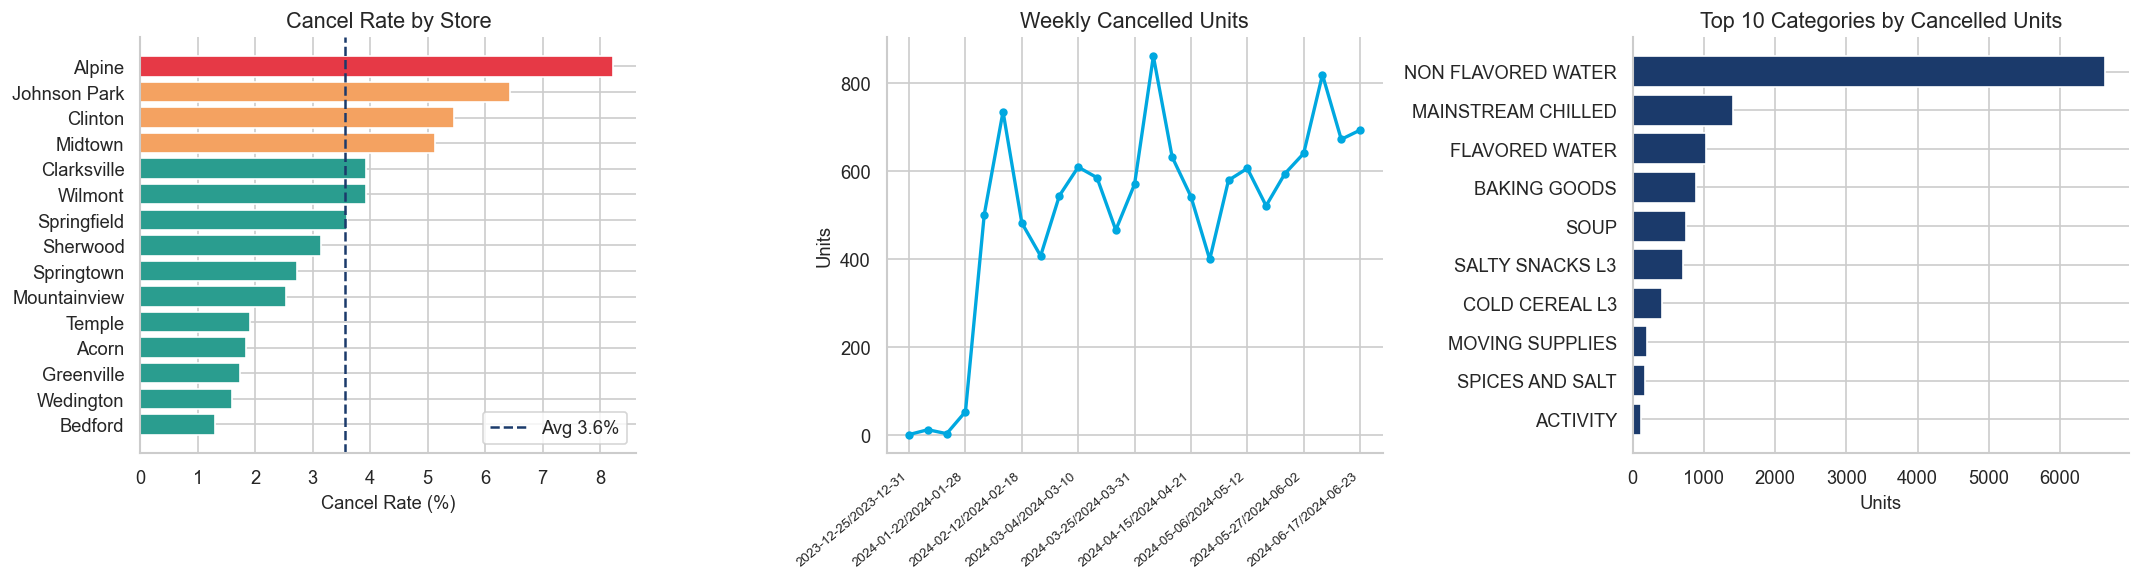

In [18]:
section("EXTENDED EDA: CANCEL RATE ANALYSIS")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Store cancel rates
crdf = cancel_rate_check.copy()
colors = [RI_RED if r >= 7 else RI_AMBER if r >= 5 else RI_GREEN
          for r in crdf["cancel_rate_pct"]]
axes[0].barh(crdf["CITY"][::-1], crdf["cancel_rate_pct"][::-1], color=colors[::-1])
axes[0].axvline(crdf["cancel_rate_pct"].mean(), color=RI_BLUE, linestyle="--",
                label=f"Avg {crdf['cancel_rate_pct'].mean():.1f}%")
axes[0].set_title("Cancel Rate by Store")
axes[0].set_xlabel("Cancel Rate (%)")
axes[0].legend()

# Weekly trend
weekly = (enriched_cancels.groupby("ORDER_WEEK")
          .agg(cancel_qty=("CNCL_QTY","sum"), cancel_amt=("CNCL_AMT","sum"))
          .reset_index().sort_values("ORDER_WEEK"))
axes[1].plot(range(len(weekly)), weekly["cancel_qty"], color=RI_TEAL, linewidth=2, marker="o", markersize=4)
axes[1].set_xticks(range(0, len(weekly), 3))
axes[1].set_xticklabels(weekly["ORDER_WEEK"].iloc[::3], rotation=40, ha="right", fontsize=8)
axes[1].set_title("Weekly Cancelled Units")
axes[1].set_ylabel("Units")

# Category breakdown
cat_agg = enriched_cancels.groupby("CATEGORY")["CNCL_QTY"].sum().sort_values(ascending=False).head(10)
axes[2].barh(cat_agg.index[::-1], cat_agg.values[::-1], color=RI_BLUE)
axes[2].set_title("Top 10 Categories by Cancelled Units")
axes[2].set_xlabel("Units")

plt.tight_layout()
plt.show()


  EXTENDED EDA: CANCEL LAG AND REASON PATTERNS


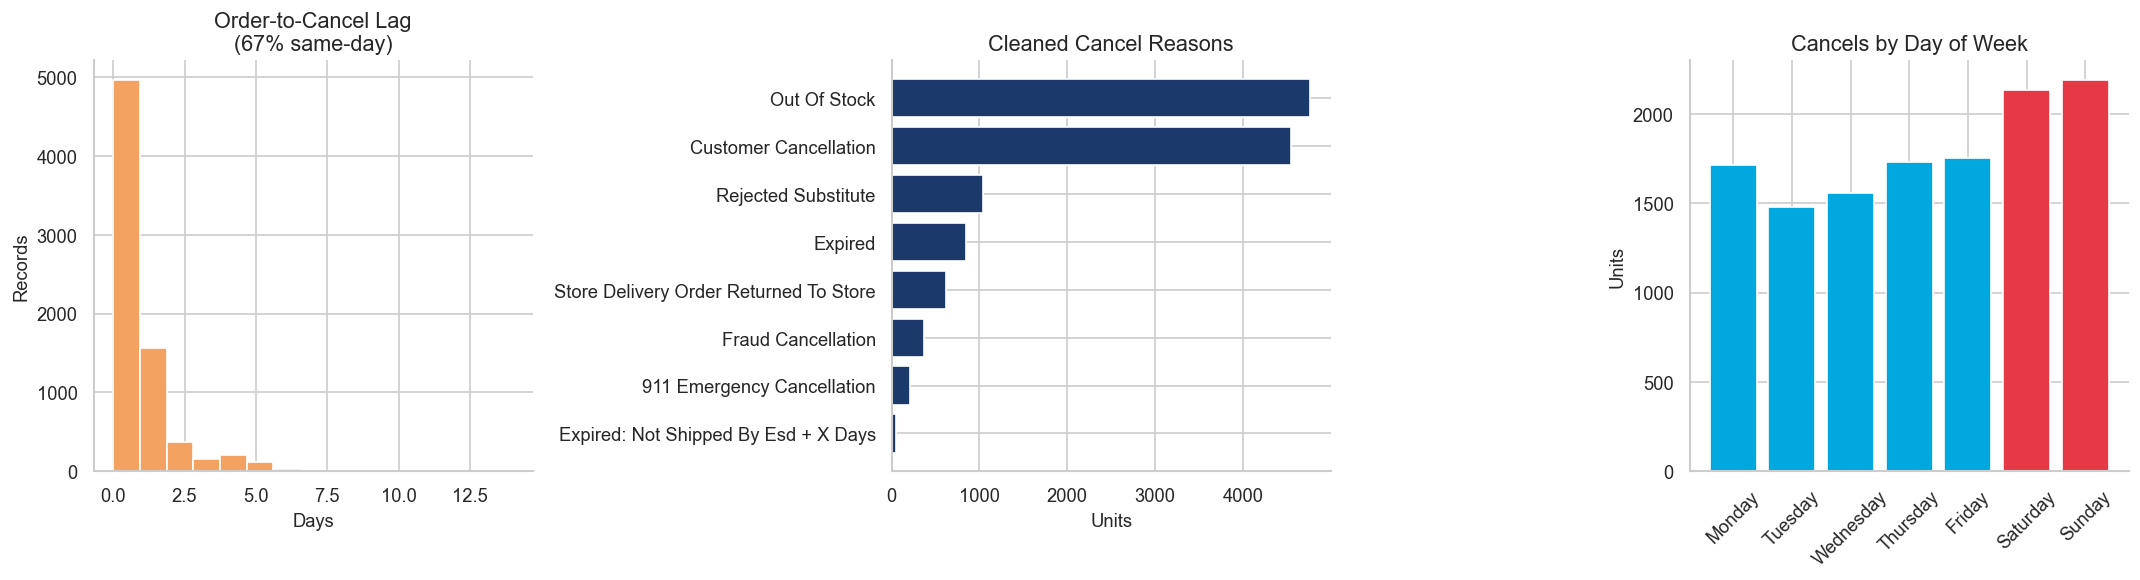

In [19]:
section("EXTENDED EDA: CANCEL LAG AND REASON PATTERNS")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cancel lag histogram
lag_data = enriched_cancels[enriched_cancels["CANCEL_LAG_DAYS"] <= 14]
axes[0].hist(lag_data["CANCEL_LAG_DAYS"], bins=15, color=RI_AMBER, edgecolor="white")
same_day_pct = (enriched_cancels["IS_SAME_DAY_CANCEL"].mean() * 100)
axes[0].set_title(f"Order-to-Cancel Lag\n({same_day_pct:.0f}% same-day)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Records")

# Cleaned reason breakdown
reason_clean = (enriched_cancels.groupby("CNCL_RSN_DESC_CLEAN")["CNCL_QTY"]
                .sum().sort_values(ascending=False).head(8))
axes[1].barh(reason_clean.index[::-1], reason_clean.values[::-1], color=RI_BLUE)
axes[1].set_title("Cleaned Cancel Reasons")
axes[1].set_xlabel("Units")

# Day of week
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_agg = (enriched_cancels.groupby("ORDER_DOW")["CNCL_QTY"].sum()
           .reindex(dow_order).fillna(0))
bar_colors = [RI_RED if d in ["Saturday","Sunday"] else RI_TEAL for d in dow_order]
axes[2].bar(dow_order, dow_agg.values, color=bar_colors)
axes[2].set_title("Cancels by Day of Week")
axes[2].set_ylabel("Units")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


  EXTENDED EDA: OOS PARADOX DEEP DIVE
OOS-flagged cancels: 2,728
Matched to inventory: 2,145


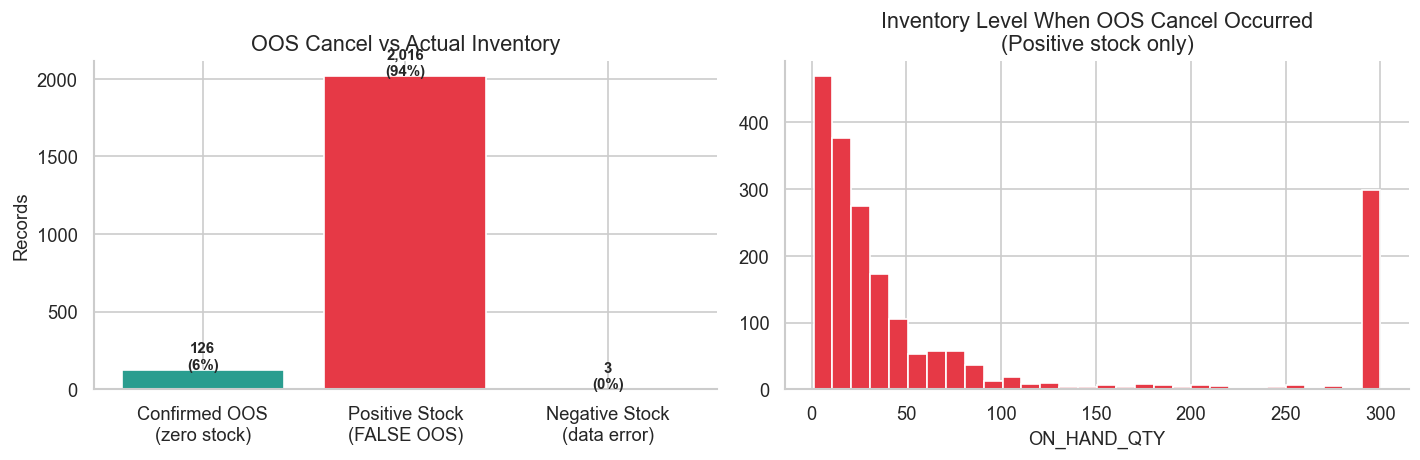


  Confirmed zero stock: 126 (6%)
  Positive stock (FALSE OOS): 2016 (94%)

  CONCLUSION: OOS reason code is unreliable in 94% of cases.


In [20]:
section("EXTENDED EDA: OOS PARADOX DEEP DIVE")

oos_df = enriched_cancels[enriched_cancels["IS_OOS_FLAG"]].copy()
oos_with_inv = oos_df.merge(
    inventory.rename(columns={"GREGORIAN_DATE":"ORDER_DT"})[
        ["STORE_NUM","ITEM_ID","ORDER_DT","ON_HAND_QTY","IS_STOCKOUT"]
    ],
    on=["STORE_NUM","ITEM_ID","ORDER_DT"], how="left"
)
matched = oos_with_inv[oos_with_inv["ON_HAND_QTY"].notna()]

print(f"OOS-flagged cancels: {len(oos_df):,}")
print(f"Matched to inventory: {len(matched):,}")

if len(matched) > 0:
    zero_count = (matched["ON_HAND_QTY"] == 0).sum()
    pos_count  = (matched["ON_HAND_QTY"] > 0).sum()
    neg_count  = (matched["ON_HAND_QTY"] < 0).sum()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(["Confirmed OOS\n(zero stock)", "Positive Stock\n(FALSE OOS)", "Negative Stock\n(data error)"],
                [zero_count, pos_count, neg_count],
                color=[RI_GREEN, RI_RED, RI_AMBER])
    axes[0].set_title("OOS Cancel vs Actual Inventory")
    axes[0].set_ylabel("Records")
    for i, v in enumerate([zero_count, pos_count, neg_count]):
        if v > 0:
            axes[0].text(i, v + 5, f"{v:,}\n({v/len(matched)*100:.0f}%)",
                         ha="center", fontsize=9, fontweight="bold")

    axes[1].hist(matched[matched["ON_HAND_QTY"] > 0]["ON_HAND_QTY"].clip(upper=300),
                 bins=30, color=RI_RED, edgecolor="white")
    axes[1].set_title("Inventory Level When OOS Cancel Occurred\n(Positive stock only)")
    axes[1].set_xlabel("ON_HAND_QTY")

    plt.tight_layout()
    plt.show()

    print(f"\n  Confirmed zero stock: {zero_count} ({zero_count/len(matched)*100:.0f}%)")
    print(f"  Positive stock (FALSE OOS): {pos_count} ({pos_count/len(matched)*100:.0f}%)")
    print(f"\n  CONCLUSION: OOS reason code is unreliable in {pos_count/len(matched)*100:.0f}% of cases.")

---
## 8. Export Processed Data to Parquet

Write all clean tables to `../data/processed/` as Parquet files.
The FastAPI pipeline loader will automatically detect and prefer these files.


In [21]:
section("EXPORTING PROCESSED DATA")

export_tables = {
    "orders":           orders,
    "cancels":          cancels,
    "inventory":        inventory,
    "store":            store,
    "product":          product,
    "calendar":         calendar,
    "enriched_cancels": enriched_cancels,
    "enriched_orders":  enriched_orders,
}

manifest = []
for name, df in export_tables.items():
    path = PROCESSED_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False, engine="pyarrow")
    size_kb = path.stat().st_size / 1024
    manifest.append({"table": name, "rows": len(df), "cols": df.shape[1],
                      "file": str(path), "size_kb": round(size_kb, 1)})
    print(f"  Wrote {name:20s}  {len(df):>8,} rows  {df.shape[1]:>3} cols  {size_kb:>8.1f} KB")

# Write manifest
manifest_path = PROCESSED_DIR / "manifest.json"
manifest_entry = {
    "generated_at": datetime.now().isoformat(),
    "tables": manifest,
    "quality_report": quality_report,
}
with open(manifest_path, "w") as f:
    json.dump(manifest_entry, f, indent=2)

print(f"\nManifest written: {manifest_path}")
print(f"\nAll processed files in: {PROCESSED_DIR.resolve()}")


  EXPORTING PROCESSED DATA
  Wrote orders                  59,068 rows   11 cols     212.0 KB
  Wrote cancels                  6,673 rows   16 cols      62.1 KB
  Wrote inventory              221,217 rows    9 cols     716.4 KB
  Wrote store                       15 rows    5 cols       3.5 KB
  Wrote product                    174 rows   12 cols      17.2 KB
  Wrote calendar                   366 rows    6 cols       7.4 KB
  Wrote enriched_cancels         7,456 rows   28 cols     109.9 KB
  Wrote enriched_orders         66,700 rows   19 cols     378.9 KB

Manifest written: ..\data\processed\manifest.json

All processed files in: C:\Hub\Projects\Titek\Data\retail_intelligence\retail\retail_insight\data\processed


---
## 9. Data Quality Report Summary


In [22]:
section("DATA QUALITY REPORT SUMMARY")

report_df = pd.DataFrame(quality_report)

passes = (report_df["status"].str.contains("PASS")).sum()
fails  = (report_df["status"].str.contains("FAIL")).sum()
total  = len(report_df)

print(f"\nTotal checks: {total}  |  PASS: {passes}  |  FAIL: {fails}")
print()

# Colour-coded display
def colour_row(row):
    colour = "#EDFAF6" if "PASS" in row["status"] else "#FFF3F3"
    return [f"background-color: {colour}"] * len(row)

styled = report_df.style.apply(colour_row, axis=1)
display(styled)

if fails > 0:
    print("\n⚠️  Action required on failed checks before using this data in production.")
else:
    print("\n✅  All checks passed. Data is ready for the pipeline.")


  DATA QUALITY REPORT SUMMARY

Total checks: 25  |  PASS: 18  |  FAIL: 7



,check,status,detail
0,Table present: ORDERS,✅ PASS,"59,068 rows"
1,Required columns: ORDERS,✅ PASS,OK
2,Table present: CANCELS,✅ PASS,"7,408 rows"
3,Required columns: CANCELS,✅ PASS,OK
4,Table present: INVENTORY,✅ PASS,"221,217 rows"
5,Required columns: INVENTORY,✅ PASS,OK
6,Table present: STORE,✅ PASS,15 rows
7,Required columns: STORE,✅ PASS,OK
8,Table present: PRODUCT,✅ PASS,174 rows
9,Required columns: PRODUCT,✅ PASS,OK



⚠️  Action required on failed checks before using this data in production.


---
## 10. Pipeline Readiness Check

Verify all required Parquet files exist and are readable by the FastAPI loader.


In [23]:
section("PIPELINE READINESS CHECK")

REQUIRED = ["orders","cancels","inventory","store","product","calendar"]
all_ready = True

for name in REQUIRED:
    path = PROCESSED_DIR / f"{name}.parquet"
    if path.exists():
        df = pd.read_parquet(path)
        print(f"  ✅  {name:20s}  {len(df):>8,} rows  verified readable")
    else:
        print(f"  ❌  {name:20s}  MISSING")
        all_ready = False

print()
if all_ready:
    print("✅  Pipeline is ready. Start the FastAPI backend with:")
    print()
    print("    uvicorn backend.main:app --reload --port 8000")
    print()
    print("The loader will automatically detect and use the processed Parquet files.")
else:
    print("❌  Some files are missing. Re-run the export section.")


  PIPELINE READINESS CHECK
  ✅  orders                  59,068 rows  verified readable
  ✅  cancels                  6,673 rows  verified readable
  ✅  inventory              221,217 rows  verified readable
  ✅  store                       15 rows  verified readable
  ✅  product                    174 rows  verified readable
  ✅  calendar                   366 rows  verified readable

✅  Pipeline is ready. Start the FastAPI backend with:

    uvicorn backend.main:app --reload --port 8000

The loader will automatically detect and use the processed Parquet files.
